In this notebook, we consider the results for the damped harmic oscillator with noise.

In [49]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import math # Keep math import
import os # Added os import
import scipy
import scipy.linalg
import gaussian_crossings.formula as formula
import gaussian_crossings.process as process
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from joblib import Parallel, delayed
from matplotlib.ticker import FixedLocator
import time


plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{amsfonts}" 
})


In [50]:
crossing_type = "upcrossing"  
# crossing_type = "downcrossing"
# crossing_type = "crossing"
ModelClass = formula.GaussianUpCrossings

mean_rate_method = f"{crossing_type}_mean_rate"
fano_method = f"{crossing_type}_fano_factor_CLT"

In [73]:
if crossing_type == "downcrossing":
    fano_label = r'$\mathrm{F}^\downarrow$'
    mean_label = r'$\mathbb{E}\left[N^\downarrow_u(T)\right]/ \,T$'
    variance_label = r'Var$\left[N^\downarrow_u(T)\right]/ \,T$'
elif crossing_type == "upcrossing":
    fano_label = r'$\mathrm{F}^\uparrow$'
    mean_label = r'$\mathbb{E}\left[N^\uparrow_u(T)\right]/ \, T$'
    variance_label = r'Var$\left[N^\uparrow_u(T)\right]/ \, T$'
else:
    fano_label = r'$\mathrm{F}$'
    mean_label = r'$\mathbb{E}\left[N_u(T)\right]/ \, T$'
    variance_label = r'Var$\left[N_u(T)\right]/ \, T$'

In [74]:
# Set simulation parameters.
T = 20.0    # Total simulation time (e.g., 10 time units)
omega0 = math.sqrt(10.0)                   # Fundamental frequency
temp = 10.0                     # Temperature (similar to sigma ** 2)
sigma = math.sqrt(temp) / omega0  # Standard deviation of the process

In [75]:
num_points_zeta = 20
zeta = torch.linspace(0.5, 3.0, num_points_zeta)

num_points_psi = 20
psi = torch.linspace(0.0, 2.0, num_points_psi)

mean_rates = torch.zeros(num_points_zeta, num_points_psi)
fano_factors = torch.zeros(num_points_zeta, num_points_psi)

In [76]:
# calculate the fano factors by parallel code
def compute_point(i, j, current_zeta, current_psi, sigma, omega0, temp, ModelClass, mean_rate_method, fano_method):
    """Calculates mean rate and Fano factor for a single parameter combination."""
    try:
        # Ensure current_zeta is a standard Python float for compatibility across processes
        zeta_val = current_zeta.item() if isinstance(current_zeta, torch.Tensor) else current_zeta

        # u is given by psi[j]*sigma, and tau_e depends on zeta[i]
        u = current_psi * sigma
        model = ModelClass(r_func=process.r_damped_harmonic_oscillator_noise, u=u, temp=temp, zeta=zeta_val, omega0=omega0)
        mr = getattr(model, mean_rate_method)()
        ff = getattr(model, fano_method)(epsilon_left=1e-5, epsilon_right=1e-5)
        # Return indices along with results
        return i, j, mr, ff
    except Exception as e:
        print(f"Error in worker for i={i}, j={j}: {e}")
        # Return NaNs or default values on error, along with indices
        return i, j, float('nan'), float('nan')

# Prepare the list of tasks (arguments for each parallel call)
tasks = []
for i in range(num_points_zeta):
    for j in range(num_points_psi):
        # Pass the actual tensor elements or values needed by compute_point
        tasks.append((i, j, zeta[i], psi[j]))

print(f"Starting parallel computation for {len(tasks)} points...")
start_time = time.time() # Optional: Start timer

# Execute in parallel
results = Parallel(n_jobs=-1, verbose=1)(
    delayed(compute_point)(
        task[0], task[1], task[2], task[3], # i, j, current_zeta, current_psi
        sigma, omega0, temp, ModelClass, mean_rate_method, fano_method # Fixed parameters
    ) for task in tasks
)

end_time = time.time() # Optional: End timer
print(f"Parallel computation finished in {end_time - start_time:.2f} seconds.")

# Process the results 
for res in results:
    if res is not None: # Basic check if the worker returned something
        i, j, mr, ff = res
        mean_rates[i, j] = mr
        fano_factors[i, j] = ff
    else:
        print("Warning: A worker task returned None.")

# find the variance
variance = fano_factors * mean_rates

Starting parallel computation for 400 points...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


Parallel computation finished in 0.97 seconds.


[Parallel(n_jobs=-1)]: Done 280 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 400 out of 400 | elapsed:    1.0s finished


In [77]:
## a standard parameter scan (old code)
# for i in range(num_points_zeta):
#     for j in range(num_points_psi):
#         # u is given by psi[j]*sigma, and tau_e depends on zeta[i]
#         u = psi[j] * sigma
#         model = ModelClass(r_func=process.r_damped_harmonic_oscillator_noise, u=u, temp=temp, zeta=zeta[i].item(), omega0=omega0)
#         mean_rates[i, j] = getattr(model, mean_rate_method)()
#         fano_factors[i, j] = getattr(model, fano_method)(epsilon_left=1e-5, epsilon_right=1e-5)

Info: Fano factor spans 1. Using custom asymmetric diverging colormap.


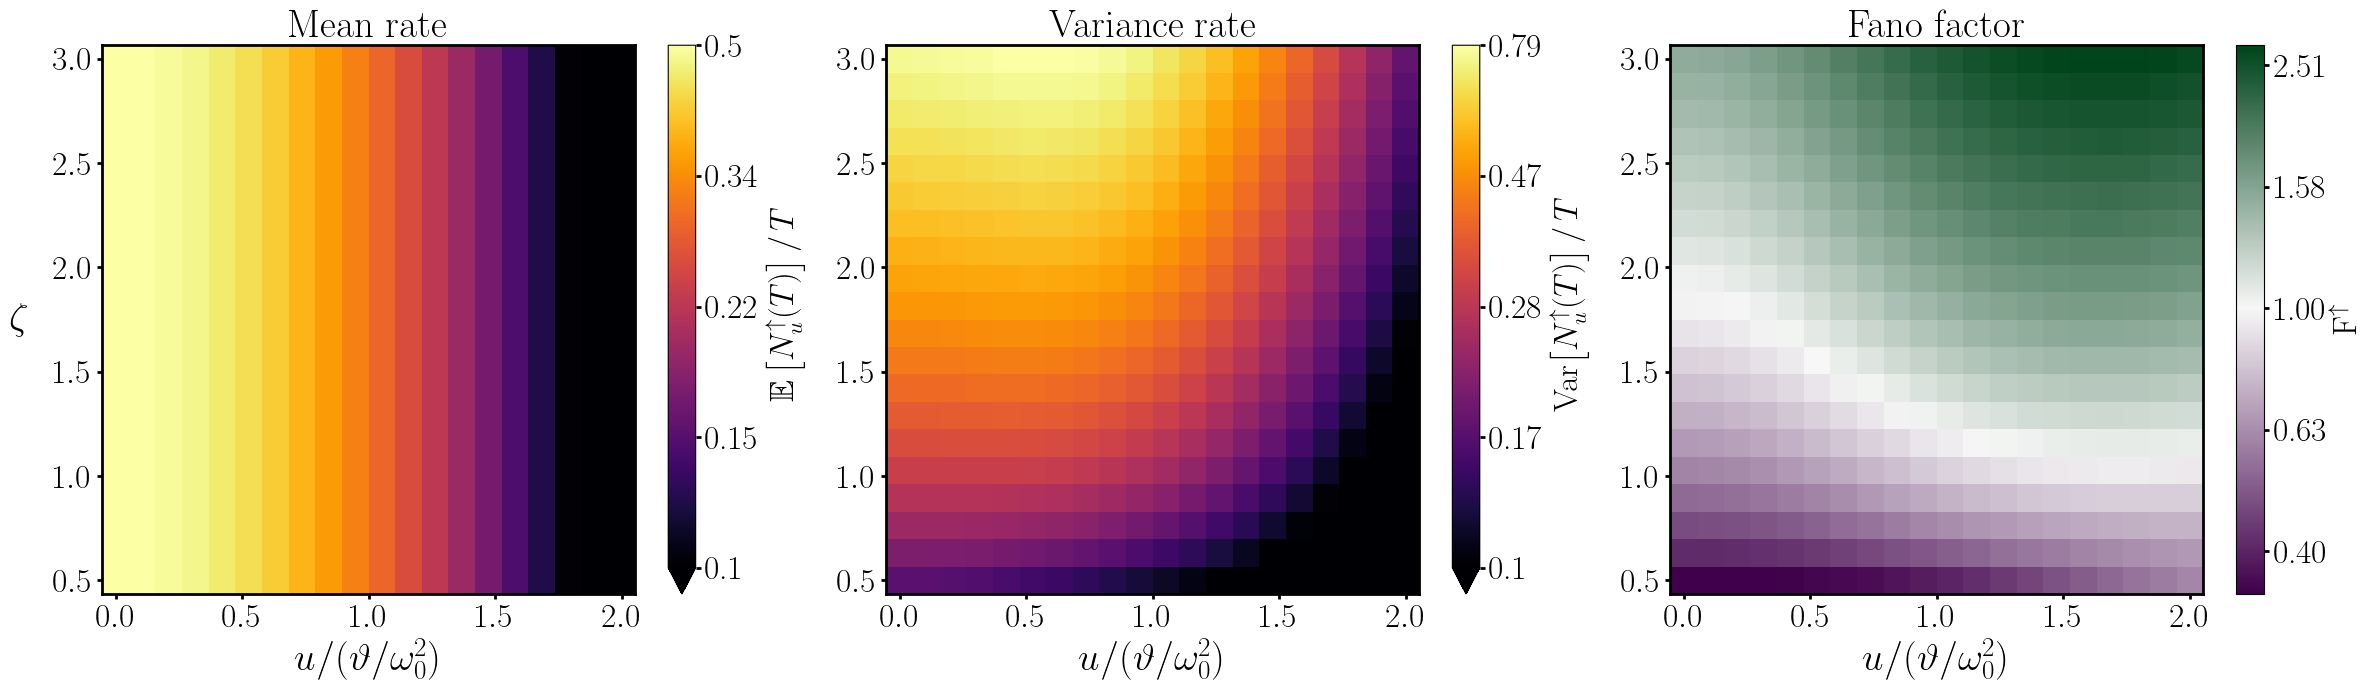

In [79]:
axis_label_fontsize = 28
tick_label_fontsize = 24
num_x_ticks = 5 # Adjusted for axis ranges
num_y_ticks = 6 # Adjusted for axis ranges (zeta 0.5-1.0)
tick_line_width = 2.0
spine_line_width = 2.0

# Colormaps (Adopted from reference code)
cmap_mean = 'inferno'
cmap_variance = 'inferno'
cmap_diverging = 'PRGn'
cmap_below_1 = 'Blues_r'
cmap_above_1 = 'Reds'

# --- Fano Factor Colormap/Normalization Logic (Linear Scale Adaptation) ---
# Use LINEAR Fano factor values
fano_min = fano_factors.min().item()
fano_max = fano_factors.max().item()
spans_one = (fano_min < 1.0) and (fano_max > 1.0)

fano_log = torch.log10(fano_factors)
fano_log_np = fano_log.cpu().numpy() # Convert to NumPy for min/max and plotting
log_min = fano_log_np.min()
log_max = fano_log_np.max()

# Select Colormap and Normalization based on range
if spans_one:
    print("Info: Fano factor spans 1. Using custom asymmetric diverging colormap.")
    if (log_max - log_min) == 0: 
        p_val = 0.5 
    else:
        p_val = (0 - log_min) / (log_max - log_min)
    p_val = np.clip(p_val, 1e-6, 1.0 - 1e-6)

    base_cmap_name = cmap_diverging 
    base_cmap_obj = plt.get_cmap(base_cmap_name)

    # Define the colors at the key points from the base diverging map
    color_for_log_min = base_cmap_obj(0.0)    # Color at the start (e.g., dark green)
    color_for_one = base_cmap_obj(0.5)        # Neutral color (e.g., white)
    color_for_log_max = base_cmap_obj(1.0)   # Color at the end (e.g., dark purple)

    segmented_colors = [
        (0.0, color_for_log_min),
        (p_val, color_for_one),
        (1.0, color_for_log_max)
    ]
    
    cmap_fano = mcolors.LinearSegmentedColormap.from_list(
        "custom_fano_cmap", segmented_colors
    )
    
    # The normalization is now a simple linear scaling over the full data range
    norm_fano = mcolors.Normalize(vmin=log_min, vmax=log_max)
else:
    if fano_max <= 1.0:
        print("Info: Max Fano factor <= 1. Using sequential colormap (below).")
        cmap_fano = cmap_below_1
    else: # fano_min >= 1.0
        print("Info: Min Fano factor >= 1. Using sequential colormap (above).")
        cmap_fano = cmap_above_1
    norm_fano = mcolors.Normalize(vmin=log_min, vmax=log_max) # Simple log normalization

# -----------------------
# Create the figure and subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# ---- Left subplot: Mean Rates ----
epsilon = 1e-1 # Standard epsilon for log norm lower bound
# Use torch.clip as in reference code
adjusted_mean_rates = torch.clip(mean_rates, epsilon, None)
# Use mcolors.LogNorm as in reference code
log_norm = mcolors.LogNorm(vmin=epsilon, vmax=adjusted_mean_rates.max()) # Use max from tensor

# Note: pcolormesh expects X, Y, C. Here X=psi, Y=zeta
pc0 = axes[0].pcolormesh(psi, zeta, adjusted_mean_rates, shading='auto', # Use tensors directly
                         cmap=cmap_mean, norm=log_norm)
cbar0 = fig.colorbar(pc0, ax=axes[0], extend='min')
# Apply new styling (from reference code)
cbar0.set_label(mean_label, fontsize=tick_label_fontsize)
cbar0.ax.tick_params(labelsize=tick_label_fontsize, width=tick_line_width)

tick_vals = np.geomspace(epsilon, adjusted_mean_rates.max().item(), 5)
cbar0.set_ticks(tick_vals)
clean_fmt = lambda v: f"{v:.2f}".rstrip("0").rstrip(".")
cbar0.ax.minorticks_off() 
cbar0.set_ticklabels([clean_fmt(v) for v in tick_vals])

# Apply new styling (from reference code)
axes[0].set_xlabel(r'$u/(\vartheta/\omega_0^2)$', fontsize=axis_label_fontsize)
axes[0].set_ylabel(r'$\zeta$', fontsize=axis_label_fontsize, rotation=0, va='center', labelpad=25) # Use zeta label, adjust padding
axes[0].set_title('Mean rate', fontsize=axis_label_fontsize)

# Apply new tick locator and styling (from reference code)
axes[0].xaxis.set_major_locator(plt.MaxNLocator(num_x_ticks))
axes[0].yaxis.set_major_locator(plt.MaxNLocator(num_y_ticks))
axes[0].tick_params(axis='both', which='major', labelsize=tick_label_fontsize, width=tick_line_width)

# Apply new spine width 
for spine in axes[0].spines.values():
    spine.set_linewidth(spine_line_width)

# ------------- Middle subplot: Variance -------------
epsilon = 1e-1
adjusted_variance = torch.clip(variance, epsilon, None)
log_norm_var = mcolors.LogNorm(vmin=epsilon, vmax=adjusted_variance.max())

pc1 = axes[1].pcolormesh(psi, zeta, adjusted_variance, shading='auto',
                         cmap=cmap_variance, norm=log_norm_var)
cbar1 = fig.colorbar(pc1, ax=axes[1], extend='min')
cbar1.set_label(variance_label, fontsize=tick_label_fontsize)
cbar1.ax.tick_params(labelsize=tick_label_fontsize, width=tick_line_width)

tick_vals = np.geomspace(epsilon, adjusted_variance.max().item(), 5)
cbar1.set_ticks(tick_vals)
cbar1.ax.minorticks_off() 
clean_fmt = lambda v: f"{v:.2f}".rstrip("0").rstrip(".")
cbar1.set_ticklabels([clean_fmt(v) for v in tick_vals])

axes[1].set_xlabel(r'$u/(\vartheta/\omega_0^2)$', fontsize=axis_label_fontsize)
# axes[1].set_ylabel(r'$\zeta$', fontsize=axis_label_fontsize, rotation=0, va='center', labelpad=25)
axes[1].set_title('Variance rate', fontsize=axis_label_fontsize)

axes[1].xaxis.set_major_locator(plt.MaxNLocator(num_x_ticks))
axes[1].yaxis.set_major_locator(plt.MaxNLocator(num_y_ticks))
axes[1].tick_params(axis='both', which='major', labelsize=tick_label_fontsize, width=tick_line_width)

for spine in axes[1].spines.values():
    spine.set_linewidth(spine_line_width)

# ---- Right subplot: Fano Factors (Log Scale) ----
pc2 = axes[2].pcolormesh(psi, zeta, fano_log_np, shading='auto', # Use numpy array for C
                         cmap=cmap_fano, norm=norm_fano)

# new code
cbar2 = fig.colorbar(pc2, ax=axes[2])
cbar2.set_label(fano_label, fontsize=tick_label_fontsize)
cbar2.ax.tick_params(labelsize=tick_label_fontsize, width=tick_line_width)

tick_locs_fano = mticker.MaxNLocator(nbins=5).tick_values(log_min, log_max)
cbar2.locator = FixedLocator(tick_locs_fano)

cbar2.formatter = mticker.FuncFormatter(lambda x, pos: f"{10**x:.2f}")
cbar2.update_ticks()

# Apply new styling (from reference code)
axes[2].set_xlabel(r'$u/(\vartheta/\omega_0^2)$', fontsize=axis_label_fontsize)
# axes[2].set_ylabel(r'$\zeta$', fontsize=axis_label_fontsize, rotation=0, va='center', labelpad=25) # Use zeta label, adjust padding
axes[2].set_title("Fano factor", fontsize=axis_label_fontsize) # Use defined fano_label

# Apply new tick locator and styling (from reference code)
axes[2].xaxis.set_major_locator(plt.MaxNLocator(num_x_ticks))
axes[2].yaxis.set_major_locator(plt.MaxNLocator(num_y_ticks))
axes[2].tick_params(axis='both', which='major', labelsize=tick_label_fontsize, width=tick_line_width)

# Apply new spine width 
for spine in axes[2].spines.values():
    spine.set_linewidth(spine_line_width)

# Apply new font size to suptitle and update process name
# fig.suptitle(f"{crossing_type} Damped Harmonic Oscillator Noise", fontsize=axis_label_fontsize) # Updated process name

plt.tight_layout()

# --- Save the figure (Adopted from reference code) ---
# Adapt folder location for the damped harmonic oscillator process
folder_loc = f'../../figures/damped_harmonic_oscillator/'
os.makedirs(folder_loc, exist_ok=True) # Create folder if it doesn't exist
file_name = f'phase_diagram_{crossing_type}'
file_save_path = os.path.join(folder_loc, file_name)

# print(f"Saving figures to: {file_save_path}")
# plt.savefig(f'{file_save_path}.png', bbox_inches='tight', dpi=300)
# plt.savefig(f'{file_save_path}.svg', format='svg', bbox_inches='tight', dpi=300)
# plt.savefig(f'{file_save_path}.eps', format='eps', bbox_inches='tight', dpi=300)

plt.show()